In [463]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
import os
import scipy
import pickle

from neurolib.models.aln import ALNModel
from neurolib.models.rate_control import RateModel
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc

plt.rcParams['image.cmap'] = 'plasma'
cpalette = sns.color_palette('plasma')
np.set_printoptions(precision=6)

font = {
    'family' : 'sans',
    'weight' : 'normal',
    'size'   : 14
       }

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=16) 
matplotlib.rc('ytick', labelsize=16) 
matplotlib.rc('grid', c='0.5', ls='-', lw=0.5)  # solid gray grid lines
matplotlib.rc('savefig', dpi=300)       # higher res outputs
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

path = os.getcwd()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [464]:
def step_control(maxI_ = 1.):
    control_ = aln.getZeroControl()
    for i_time in range(control_.shape[2]):
        if ( float(i_time/control_.shape[2]) < 0.1):
            control_[:,:2,i_time] = - maxI_
        elif ( float(i_time/control_.shape[2]) > 0.5 and float(i_time/control_.shape[2]) < 0.6 ):
            control_[:,:2,i_time] = maxI_
    return control_

In [465]:
def setinitvars(vars):
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                if aln.params[init_vars[iv]].ndim == 2:
                    aln.params[init_vars[iv]][0,:] = vars[sv]
                else:
                    aln.params[init_vars[iv]][:] = vars[sv]
                    

In [466]:
tol = 1e-32

c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

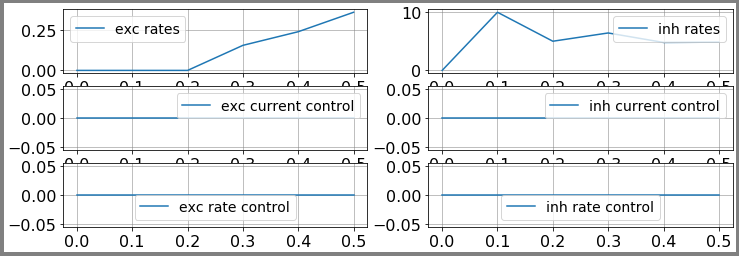

In [500]:
aln = RateModel()

aln.params['duration'] = 0.5
aln.params.dt = 0.1
control0 = aln.getZeroControl()

# NO ADAPTATION
aln.params.IA_init = np.array([0.])
aln.params.a = 0.
aln.params.b = 0.

# no noise
aln.params.sigma_ou = 0.
aln.params.mue_ext_mean = 0.
aln.params.mui_ext_mean = 0.
aln.params.sigmae_ext = 0.
aln.params.sigmai_ext = 0.
aln.params.ext_exc_current = 0.
aln.params.ext_inh_current = 0.

# no delay
aln.params.signalV = 0.
aln.params.de = 0.
aln.params.di = 0.

aln.params.cie = 1.
aln.params.Jie_max = 1.
aln.params.tau_se = 1.
aln.params.tau_si = 1.
aln.params.C = 1.
aln.params.gL = 1.
aln.params.Ke = 1000.
aln.params.Ki = 1000.
aln.params.c_gl *= 5.

plotFunc.plot_traces(aln, control0)

output = aln.output_vars

state_vars = aln.state_vars
init_vars = aln.init_vars

high_state_vars = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        high_state_vars[i] = aln.state[state_vars[i]][0]
    else:
        high_state_vars[i] = aln.state[state_vars[i]][0,-2]

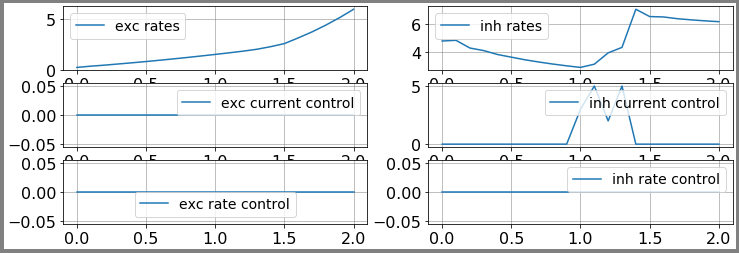

delay : 
exc rates :  [0.23932845 0.35948714 0.46100716 0.5764934  0.69180858 0.81512182
 0.94285241 1.07678837 1.21604506 1.36092763 1.51120171 1.66688564
 1.8279108  2.01411708 2.26712863 2.5714817  3.1275593  3.71850592
 4.38507466 5.12043813 5.93070984]
inh rates :  [4.80834722 4.85953963 4.31453139 4.13173711 3.85478758 3.66560745
 3.47758461 3.3208701  3.17841699 3.05334852 2.94128725 3.16829091
 3.97033649 4.35800501 7.05465549 6.53871275 6.51077609 6.38804785
 6.30575201 6.23483718 6.17676845]
sigmae_f  [[0.32512074 0.39797449 0.47160388 0.53697556 0.59957764 0.65798351
  0.71352302 0.7662137  0.81652991 0.86468774 0.9109506  0.95551556
  1.00351997 1.06367658 1.12970696 1.23659568 1.33566708 1.43431521
  1.53110381 1.62664551 3.51402377]]
target [[[1.21604506 1.36092763 1.51120171 1.66688564 1.8279108  2.01411708
   2.26712863 2.5714817  3.1275593  3.71850592 4.38507466 5.12043813
   5.93070984]
  [3.17841699 3.05334852 2.94128725 3.16829091 3.97033649 4.35800501
   7.05465549

In [502]:
dur = 1.2
dur_pre = 0.8
dur_post = 0.8

n_dur = int(dur/aln.params.dt + 1)
n_pre = int(dur_pre/aln.params.dt + 1)

aln.params.duration = dur + dur_pre

control_ind = [1]
prec_var = [0]

if control_ind[0] == 0 or control_ind[0] == 1:
    max_cntrl = 5.
    min_cntrl = -5.
else:
    max_cntrl = 0.5
    min_cntrl = 0.

control0 = aln.getZeroControl()
#control0[0,control_ind,:] =  np.sin(np.arange(0,dur+1, 1))
#control0[0,control_ind,0] = 1.
for j in control_ind:
    #control0[0,j,n_pre + 0] = 1.0 * max_cntrl - 0.0 * min_cntrl
    control0[0,j,n_pre + 1] = 0.4 * max_cntrl - 0.2 * min_cntrl
    control0[0,j,n_pre + 2] = 0.8 * max_cntrl - 0.2 * min_cntrl
    control0[0,j,n_pre + 3] = 0.2 * max_cntrl - 0.2 * min_cntrl
    control0[0,j,n_pre + 4] = 0.6 * max_cntrl - 0.4 * min_cntrl
    #control0[0,j,n_pre + 5] = 0.5 * max_cntrl - 0.6 * min_cntrl
    #control0[0,j,n_pre + 6] = 1.0 * max_cntrl - 0.8 * min_cntrl

setinitvars(high_state_vars)
#aln.params.de = 0.3
#aln.params.di = 0.2
plotFunc.plot_traces(aln, control0)
print("delay : ")
print("exc rates : ", aln.rates_exc[0,:])
print("inh rates : ", aln.rates_inh[0,:])

aln.params.duration = dur
target = aln.getZeroTarget()
target[0,0,:] = aln.rates_exc[0,n_pre-1:]
target[0,1,:] = aln.rates_inh[0,n_pre-1:]

print("sigmae_f ", aln.state["sigmae_f"])
print("target", target)

In [503]:
costparams = [1. * 1e0, 1.* 1e-2, 1.* 1e-2]
cost.setParams(costparams[0], costparams[1], costparams[2])

setinitvars(high_state_vars)
max_it = 200
start_step = 1.
alg = "A1"
case = "test"

aln.params.duration = dur
control1 = aln.getZeroControl()
#control1[0,0,1] = 4.344642
#control2 = bestControlA
control2 = bestControlA[:,:,n_pre-1:-n_pre+1]
#control2[0,0,4:] = 0.

cvar = [None, "HS", "FR", "PR", "HZ"]
cgv = cvar[0]

bestControlA, bestStateA, costA, runtimeA, grad = aln.A1(control1, target, c_scheme, u_mat, u_scheme,
        max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl, 
        min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post,
        CGVar = cgv, control_variables_ = control_ind, prec_variables_ = prec_var)

for j in control_ind:
    print("control ind ", j )
    print("grad = ", grad[0,j,:])
    print("best control = ", bestControlA[0,j,:])

for i in range(1, len(costA)):
    if costA[i-1] < costA[i]:
        print("ERROR ---------------- in index ", i)
        
print("total runtime = ", runtimeA[-1])
# 0.0023455659049372796
# 0.002345565904937199

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


set cost params
RUN  0 , total integrated cost =  0.7280975686405156
RUN  1 , total integrated cost =  0.04373722696104591
RUN  2 , total integrated cost =  0.0395237674277608
RUN  3 , total integrated cost =  0.03952078095730533
RUN  4 , total integrated cost =  0.03952078095730531
RUN  5 , total integrated cost =  0.039520780957305296
RUN  6 , total integrated cost =  0.03952078095730528
RUN  7 , total integrated cost =  0.03952078095730528
Control only changes marginally.
Improved over  7  iterations by  94.57204876661002  percent.
Problem in initial value trasfer:  sigmae_f 2.7303283598866095 0.8165299105643885
Problem in initial value trasfer:  sigmae_f 3.515240467239747 1.735978663607491
control ind  1
grad =  [0.         0.04456298 0.03849802 0.03249506 0.02671014 0.02135384
 0.01701372 0.01320164 0.00958193 0.00569799 0.00327274 0.
 0.        ]
best control =  [0.         0.         0.         0.         0.         0.
 0.         0.         0.         3.35024474 2.94437901 2.53

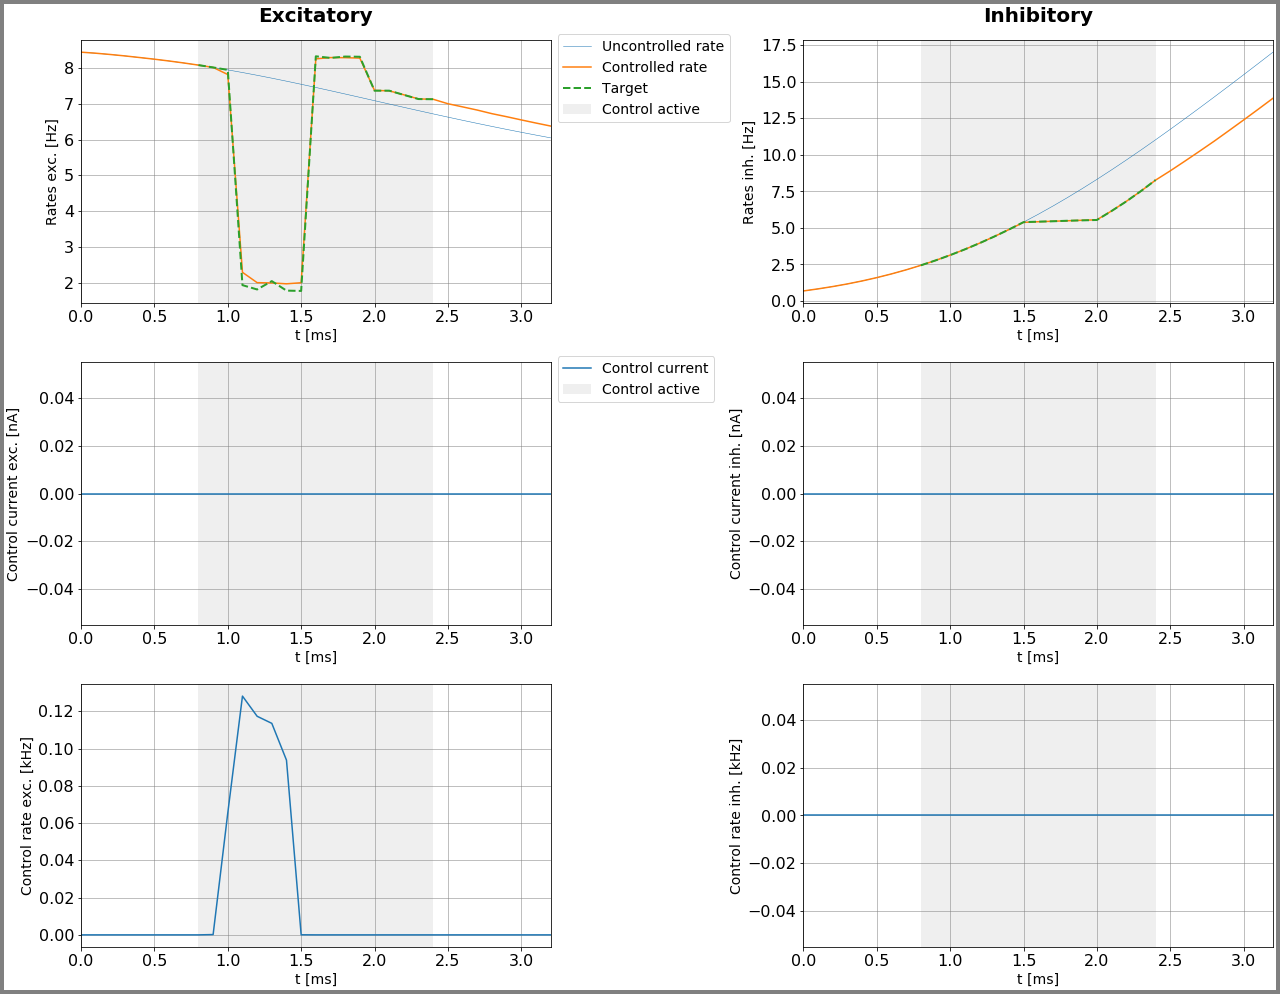

In [473]:
plotFunc.plot_control(aln, bestControlA, dur, dur_pre, dur_post, high_state_vars, target, path)

In [86]:
cost.setParams(costparams[0], costparams[1], costparams[2])
setinitvars(high_state_vars)
max_it = 100
start_step = 1.
alg = "A2"
case = "test"
incl_step = 10
test_step = 1e-6

aln.params.duration = dur
control3 = aln.getZeroControl()
#control4 = bestControlA_A2[:,:,n_pre-1:-n_pre+1]


print(max_cntrl, min_cntrl)

bestControlA_A2, bestStateA_A2, costA_A2, runtimeA_A2 = aln.A2(control3, target,
        max_iteration_ = max_it,  tolerance_ = tol, include_timestep_ = incl_step,
        start_step_ = start_step, test_step_ = test_step, max_control_ = max_cntrl,
        min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre,
        t_sim_post_ = dur_post, control_variables_ = control_ind, prec_variables_ = prec_var)

#0.003933378523157236

ERROR:root:not implemented for less than full timesteps


set cost params
1.0 -1.0
RUN  0 , total integrated cost:  0.00136
RUN  1 , total integrated cost:  0.0005530623722076417
RUN  2 , total integrated cost:  0.00044936871067183996
RUN  3 , total integrated cost:  0.0004277012781754202
RUN  4 , total integrated cost:  0.0004191314764336925
RUN  5 , total integrated cost:  0.00041755282506943645
RUN  6 , total integrated cost:  0.00041858942587726957
RUN  7 , total integrated cost:  0.0004217109068687648
RUN  8 , total integrated cost:  0.0004210672217629987
RUN  9 , total integrated cost:  0.00042071950397816455
RUN  10 , total integrated cost:  0.00042048372728892107
RUN  11 , total integrated cost:  0.00042033843691662086
RUN  12 , total integrated cost:  0.0004203842892348858
RUN  13 , total integrated cost:  0.00042038194935269184
RUN  14 , total integrated cost:  0.0004203819134389507
RUN  15 , total integrated cost:  0.0004203819130942231
RUN  16 , total integrated cost:  0.00042038191306729175
RUN  17 , total integrated cost:  0.000

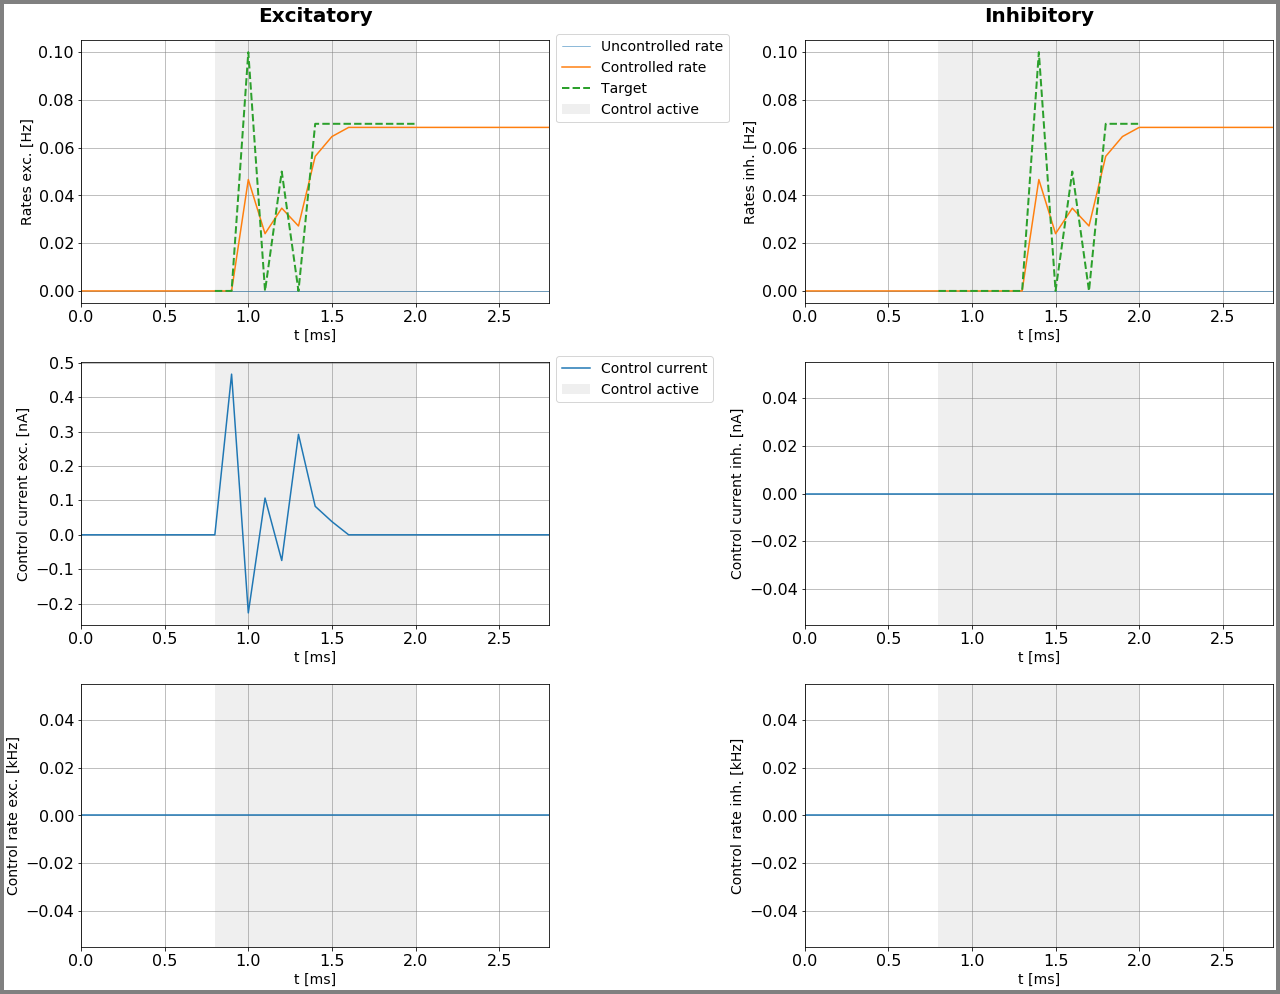

In [88]:
plotFunc.plot_control(aln, bestControlA_A2, dur, dur_pre, dur_post, high_state_vars, target, path)

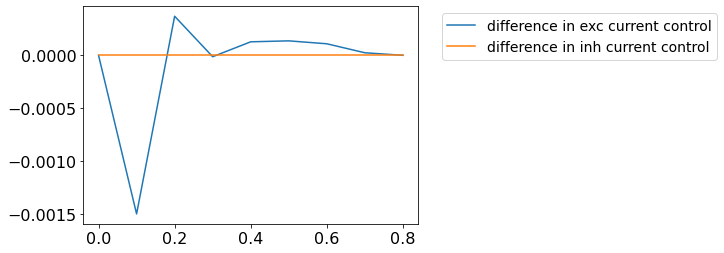

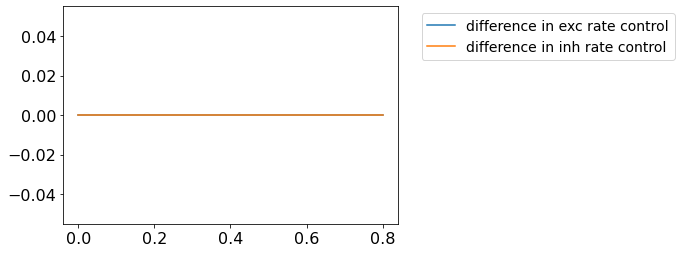

In [114]:
diff = bestControlA - bestControlA_A2
#diff[0,2,-2:] = 0.

#c_diff = costA_A2[6] - costA[3]
#print(c_diff)

t = np.arange(0,dur+0.1, 0.1)

plt.plot(t, diff[0,0,:], label="difference in exc current control")
plt.plot(t, diff[0,1,:], label="difference in inh current control")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.show()

plt.plot(t, diff[0,2,:], label="difference in exc rate control")
plt.plot(t, diff[0,3,:], label="difference in inh rate control")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.show()

### Testcases

1. PRECISION ONLY, NO DELAY
    - [x] 0 control, 0 precision measure, no delay
    - [x] 1 control, 1 precision measure, no delay
    - [x] 0 control, 1 precision measure, no delay
    - [x] 1 control, 0 precision measure, no delay
    - [] 2 control, 0 precision measure, no delay (slow to converge)
    - [] 2 control, 1 precision measure, no delay (slow to converge)

2. PRECISON + ENERGY + SPARSITY, NO DELAY
    - [x] 0 control, 0 precision measure, no delay
    - [x] 1 control, 1 precision measure, no delay
    - [] 0 control, 1 precision measure, no delay (requires different weights, gradient vanishes, A2 performes differently and worse)
    - [] 1 control, 0 precision measure, no delay (requires different weights, gradient vanishes, A2 performes differently and worse)
    - [x] 2 control, 0 precision measure, no delay
    - [] 2 control, 1 precision measure, no delay (requires different weights, zero control as output, gradient nonvanishing because on boundary. At higher weights, gradient vanishes)
    
3. PRECISION ONLY, DELAY
    - [x] 0 control, 0 precision measure, delay
    - [x] 1 control, 1 precision measure, delay
    - [] 0 control, 1 precision measure, delay (not in every case, could have several solutions)
    - [] 1 control, 0 precision measure, delay (not in every case, could have several solutions)
    - [x] 2 control, 0 precision measure, delay (sometimes slow convergence)
    - [x] 2 control, 1 precision measure, delay (sometimes slow to converge)

4. PRECISON + ENERGY + SPARSITY
    - [] 0 control, 0 precision measure, delay (gradient does not quite vanish)
    - [] 1 control, 1 precision measure, delay (gradient does not quite vanish)
    - [] 0 control, 1 precision measure, delay (requires different weights, gradient does not quite vanish, A2 performes differently and worse)
    - [] 1 control, 0 precision measure, delay (requires different weights, gradient does not quite vanish, A2 performes differently and worse)
    - [] 2 control, 0 precision measure, delay (gradient does not quite vanish)
    - [] 2 control, 1 precision measure, delay (requires different weights, gradient does not quite vanish, A2 performes differently and worse)
    
The cost functional should always have more than one minimum. If the "direct" control (0,0; 1,1; 2,0; 3,1) is not applied, it is much more likely to end up in a local minimum, because there is no "dominant" contribution.